<a href="https://colab.research.google.com/github/wantuds-crypto/Ciencia-datos-curso/blob/main/Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("debayank2024/house-price-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'house-price-prediction' dataset.
Path to dataset files: /kaggle/input/house-price-prediction


In [32]:
import os
df = pd.read_csv(os.path.join(path, "modified_data.csv"))
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   object 
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   object 
 15  city            4600 non-null   object 
 16  statezip        4600 non-null   object 
 17  price_per_sqft  4600 non-null   f

In [33]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


Preguntas y decisiones para el trabajo

**por que razon dejamos los datos nulos
**por que razon usamos la media
**por que razon eliminados 100 registros y asi

In [34]:
df.select_dtypes(include=['number']).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price           4600 non-null   float64
 1   bedrooms        4600 non-null   float64
 2   bathrooms       4600 non-null   float64
 3   sqft_living     4600 non-null   int64  
 4   sqft_lot        4600 non-null   int64  
 5   floors          4600 non-null   float64
 6   waterfront      4600 non-null   int64  
 7   view            4600 non-null   int64  
 8   condition       4600 non-null   int64  
 9   sqft_above      4600 non-null   int64  
 10  sqft_basement   4600 non-null   int64  
 11  yr_built        4600 non-null   int64  
 12  yr_renovated    4600 non-null   int64  
 13  price_per_sqft  4600 non-null   float64
dtypes: float64(5), int64(9)
memory usage: 503.3 KB


In [35]:
df.select_dtypes(include=['bool']).info()
df.select_dtypes(include=['object']).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Empty DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      4600 non-null   object
 1   street    4600 non-null   object
 2   city      4600 non-null   object
 3   statezip  4600 non-null   object
dtypes: object(4)
memory usage: 143.9+ KB


###Analsis Inicial:
### Nominales
- `street`, `city`, `statezip`
### Ordinales
- `condition` , `view` , `floors`
### Booleanas
- `waterfront`


### Numéricas (no nominal / ordinal / booleana)
- `price`, `sqft_living`, `sqft_lot`, `sqft_above`, `sqft_basement`, `price_per_sqft`: variables de razón (ratio), con cero absoluto y proporciones con sentido.
- `bedrooms`, `bathrooms`: conteos discretos, también de razón.
- `yr_built`, `yr_renovated`: años, de intervalo. En `yr_renovated`, el valor 0 es un centinela que significa "nunca renovada", no un año real.
- `date`: fecha/hora, un tipo de dato temporal aparte.

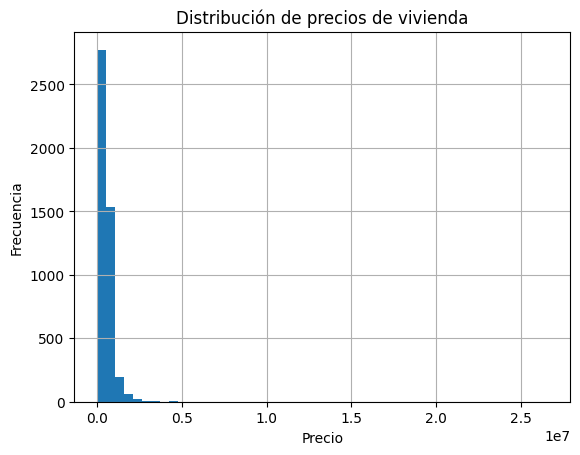

In [37]:
import matplotlib.pyplot as plt

df['price'].hist(bins=50)
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.title('Distribución de precios de vivienda')
plt.show()